In [ ]:
#This python notebook is for a hands-on tutorial on the conception of pulsar search, the material is developed by Jason Hessels
#The input file is a dedispersed timeseries from LOFAR of the original pulsar PSR B1919+21
#The data is provided by Ziggy Pleunis and Jason Hessels of U. Amsterdam and ASTRON

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage

#Read file to get the time series (ts)
ts = np.fromfile("L197621_SAP0_BEAM1_DM12.44_Mask.dat", dtype=np.float32)

#Check the length of the time series to find out the total number of samples. 
nsamp = 

#The sampling rate of this observation
tsamp = 0.00262143998406827

#The integration time (t)
t = np.arange(nsamp) * tsamp

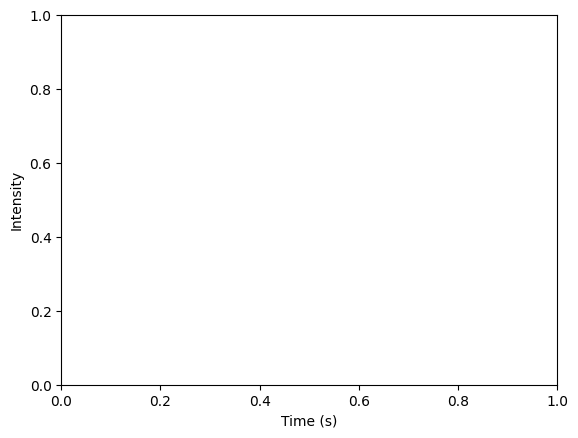

In [8]:
# check data
plt.plot(t, ts)
plt.ylabel("Intensity")
plt.xlabel("Time (s)")
plt.show()


Text(0.5, 0, 'Time (s)')

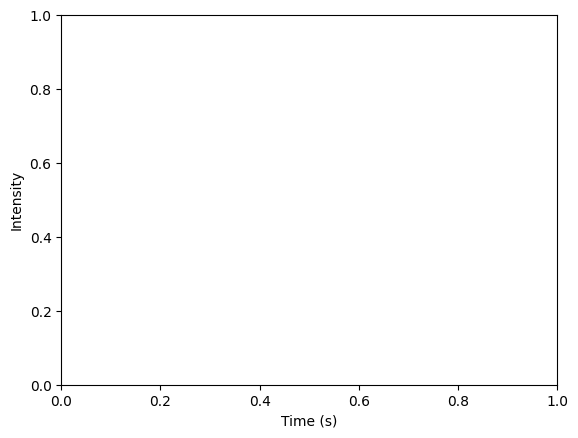

In [10]:
# The baseline of this time series is not flat, we will need to filter out this red noise
# Hint: use scipy.ndimage.uniform_filter1d to calculate a running mean in order to normalize the data
# Hint: need to play with window size when data and/or tsamp changes

running_mean = 
normalized = 
plt.plot(t, normalized)
plt.ylabel("Intensity")
plt.xlabel("Time (s)")

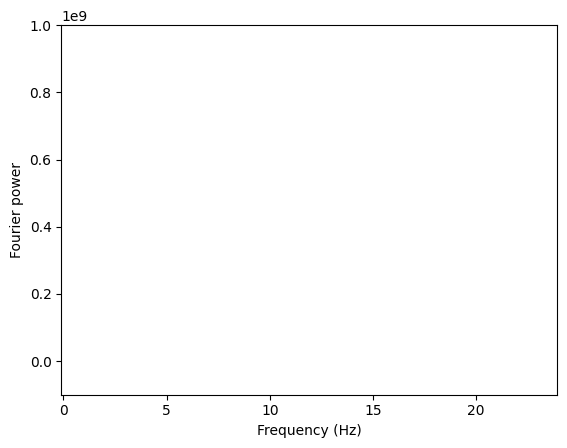

In [13]:
# Run a Fourier transform on the time series ts to find any periodicity in the data
# Hint: use np.fft.rfft and np.fft.rfftfreq
fft = 
xf = 
plt.plot(xf, fft)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")


# Add to the plot the spin period of PSR B1919+21 to see if they match up
# Hint: get the spin period in seconds from the internet, e.g. the ATNF catalog https://www.atnf.csiro.au/research/pulsar/psrcat/
p0 = 
f0 = 

# plot harmonics
for i in range(1, 32):
    plt.axvline(i * f0, color="tab:orange", ls=":")
plt.xlim(-0.1, f0 * 32)
plt.ylim(-0.1e9, 1e9)

plt.show()

(-100000000.0, 1000000000.0)

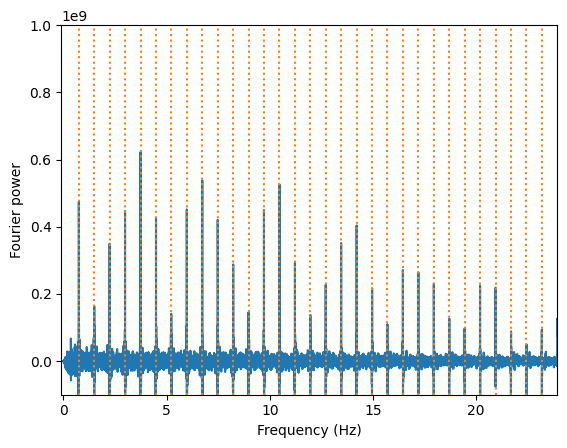

In [5]:
# a zero-padded FFT (adding zeroes at the end; could infinitely do this, but cost is compute)
zero_padded = np.append(norm, np.zeros_like(norm))
fft = np.fft.rfft(zero_padded)[1:]
xf = np.fft.rfftfreq(n=zero_padded.size, d=tsamp)[1:]
plt.plot(xf, fft)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")
p0 = 1.3373
f0 = 1 / p0

#plot harmonics
for i in range(1, 32):
    plt.axvline(i * f0, color="tab:orange", ls=":")
plt.xlim(-0.1, f0 * 32)
plt.ylim(-0.1e9, 1e9)

Text(0, 0.5, 'Fourier power')

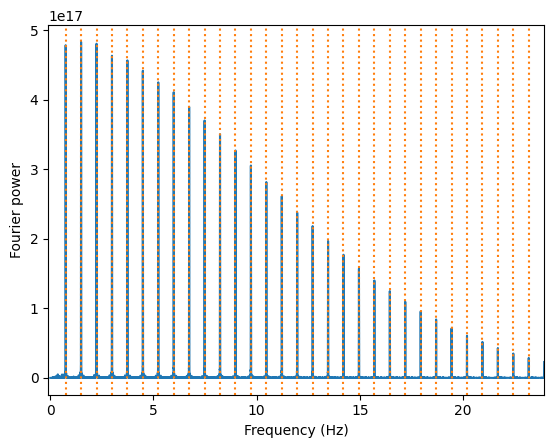

In [6]:
# interbinning; see the pulsar handbook
# the idea here is to catch when the FFT bins do not match well with where the actual power in the FT is
interbinning = np.max(np.vstack((np.abs(fft[:-2] + fft[1:-1]) ** 2 / 2,
    np.abs(fft[1:-1]) ** 2, np.abs(fft[1:-1] + fft[2:]) ** 2 / 2)), axis=0)
plt.plot(xf[1:-1], interbinning)
plt.xlim(-0.1, f0 * 32)
# plot harmonics
for i in range(1, 32):
    plt.axvline(i * f0, color="tab:orange", ls=":")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")

Text(0.5, 0, 'Phase')

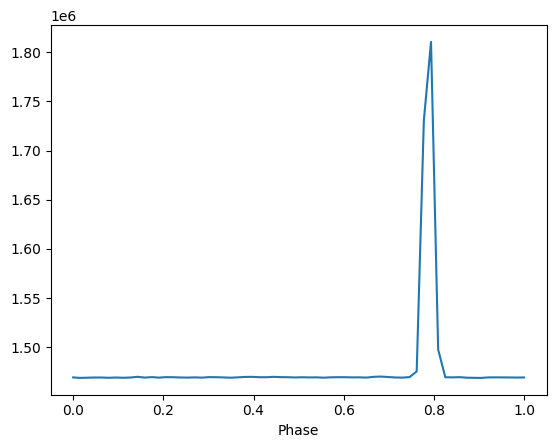

In [7]:
# plot power
# here's a probably optimal way of calculating `nbin` from Cees:
# int(2 ** np.floor(np.log2(p0 / tsamp)))
nbin = 64

# calculate pulse phase for each time step
phase = np.mod(t / p0, 1.0)

# calculate bin to add timestep to
ibin = (nbin * phase).astype("int")

data_sum = np.zeros(nbin)
data_count = np.zeros(nbin)

# sum data and sum counts in each bin
np.add.at(data_sum, ibin, ts)
np.add.at(data_count, ibin, 1.0)

# average in each bin
pulse_profile = data_sum / data_count

# plot profile
xt = np.linspace(0, 1, nbin)
plt.plot(xt, pulse_profile)
plt.xlabel("Phase")

/var/folders/g4/9xmh6cjn4zn7r24hvcfswgz1wj7pk0/T/ipykernel_58684/4109224748.py:21: RuntimeWarning: invalid value encountered in divide
  data = data_sum / data_count


Text(0.5, 0, 'Phase')

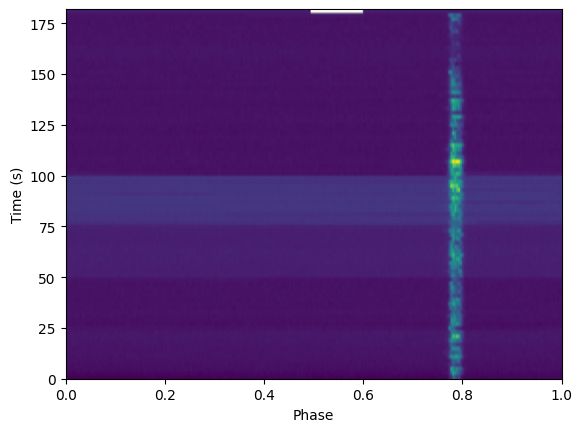

In [8]:
# create a dynamic profile
tsub = 2.0
tmax = np.max(t)
nsub = int(np.ceil(tmax / tsub))

fbin = p0 / tsamp
nbin = int(2 ** np.floor(np.log2(fbin)))

data_sum = np.zeros((nsub, nbin))
data_count = np.zeros((nsub, nbin))

phase = np.mod(t / p0, 1.0)

ibin = (nbin * phase).astype("int")

isub = (t / tsub).astype("int")

np.add.at(data_sum, (isub, ibin), ts)
np.add.at(data_count, (isub, ibin), 1.0)

data = data_sum / data_count

plt.imshow(data, origin="lower", aspect="auto", extent=[0, 1, 0, nsub * tsub])
plt.ylabel("Time (s)")
plt.xlabel("Phase")

In [14]:
# This pulsar is actually in a binary system. The orbital motion means that the observed spin period varies with time
# Try to detect this change by repeating the FFT calculation but for smaller chunk of data 
# For example, collect 10+ pairs of [time,spin_freq] and fill them into arrays mjd and frequencies

mjd = np.array([
    
])

frequencies = np.array([
    
])

p0s = 1 / frequencies

/var/folders/g4/9xmh6cjn4zn7r24hvcfswgz1wj7pk0/T/ipykernel_61743/3232014801.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Spin period (ms)')

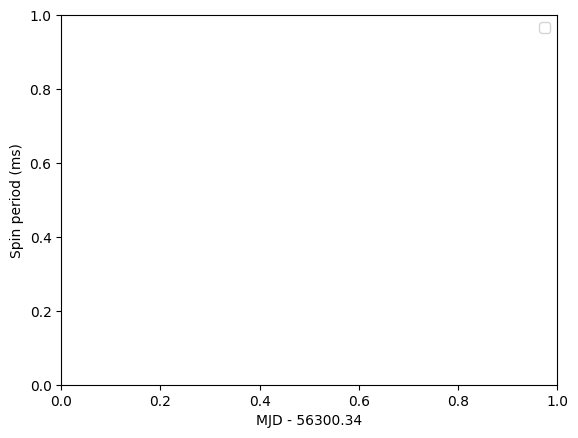

In [32]:
# fitting binary orbit

def binary_orbit(t, amp, pb, phase, offset):
    return amp * np.sin(2 * np.pi * (1 / pb) * t + phase) + offset

# This need to start at zero so we subtract np.min(mjd)
xt = np.linspace(np.min(mjd), np.max(mjd), 1000) - np.min(mjd)

# Plot the 10+ pairs of data obtained, and try to guess the binary orbit
plt.errorbar(mjd - np.min(mjd), p0s * 1000, fmt=".", color="tab:blue")
amp_guess = 
pb_guess = 
phase_guess = np.pi
offset_guess = 
#Feed these 5 input parameters to function(binary_orbit) to get a guess of the orbit
orbit_guess = 
plt.plot(xt, orbit_guess, label="guess")

# Use scipy.optimize.curve_fit to fit to the 10 pairs of data collected
import scipy.optimize
popt, pcov = 
#Feed the popt obtained to function(binary_orbit) to get a fit of the orbit
orbit_fitted = 
plt.plot(xt, orbit_fitted , label="fit")

plt.legend()
plt.xlabel("MJD - {:.2f}".format(np.min(mjd)))
plt.ylabel("Spin period (ms)")